## Imports

In [2]:
import pandas as pd
import numpy as np
import re
import json
import time
from IPython.display import display
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Read dataset

In [3]:
DATA_PATH = '/content/drive/MyDrive/Course_data'
insurance = pd.read_csv(f'{DATA_PATH}/insurance.csv')
insurance


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Exploratory Data Analysis

In [4]:
print("Duplicates in insurance:", insurance.duplicated().sum())


Duplicates in insurance: 1


In [5]:
duplicates = insurance[insurance.duplicated(keep=False)]
print("Duplicate rows:")
print(duplicates.sort_values(by=list(insurance.columns)))


Duplicate rows:
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


In [6]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


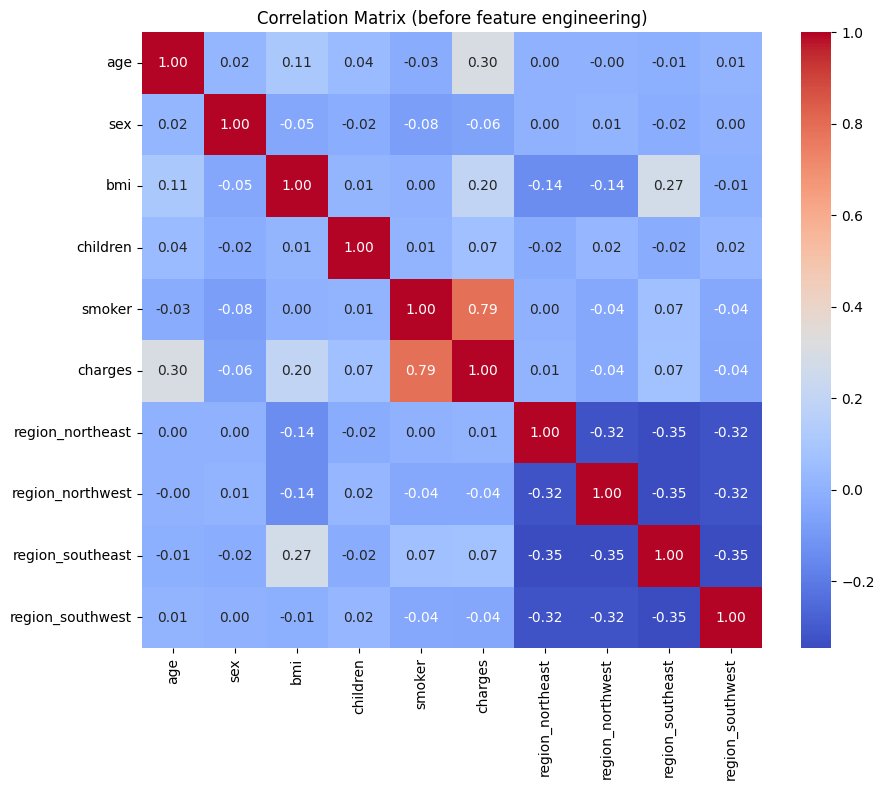

In [8]:
df_temp = insurance.copy()
df_temp['sex'] = df_temp['sex'].map({'male': 0, 'female': 1})
df_temp['smoker'] = df_temp['smoker'].map({'yes': 1, 'no': 0})
df_temp = pd.get_dummies(df_temp, columns=['region'])
corr_matrix = df_temp.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (before feature engineering)")
plt.show()


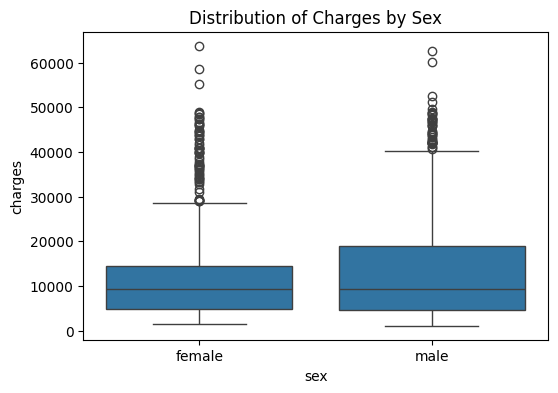

In [9]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='sex', y='charges', data=insurance)
plt.title("Distribution of Charges by Sex")
plt.show()


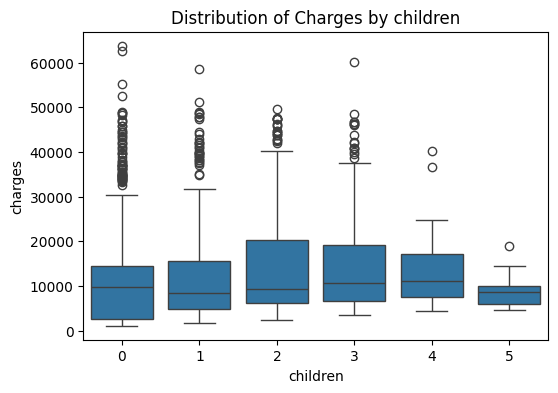

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='children', y='charges', data=insurance)
plt.title("Distribution of Charges by children")
plt.show()


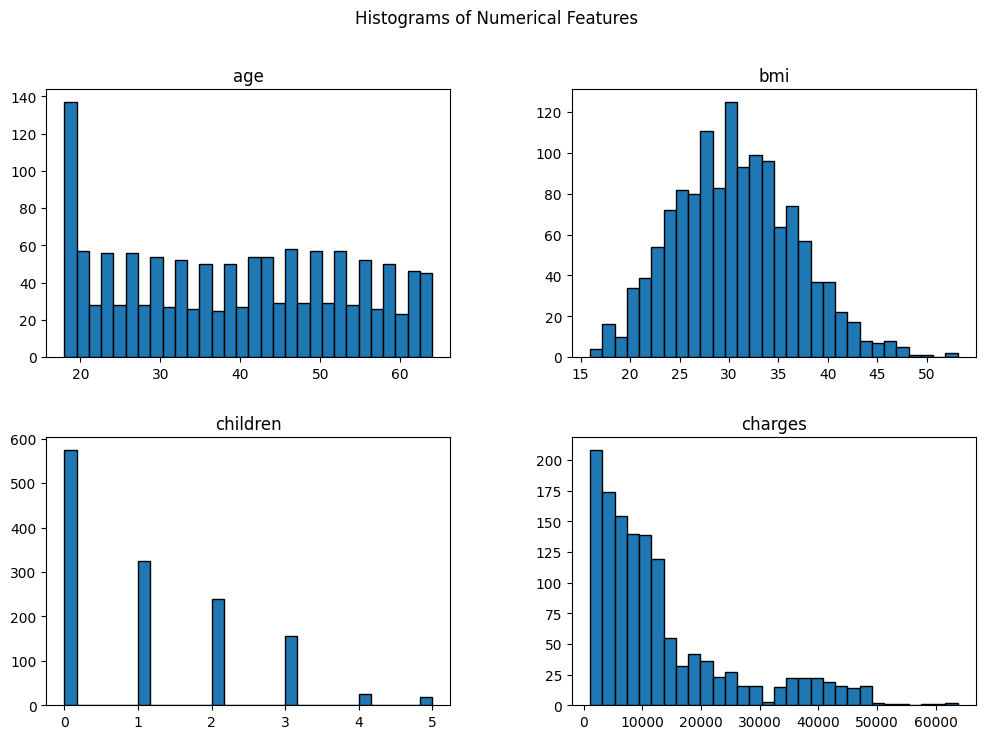

In [11]:
numerical_cols = ['age', 'bmi', 'children', 'charges']
insurance[numerical_cols].hist(bins=30, figsize=(12, 8), grid=False, edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.show()


# x, y — Drop duplicates & define target

In [12]:
insurance.drop_duplicates(inplace=True)

x = insurance.drop('charges', axis=1)
y = insurance['charges']



# Train / Test Split

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train size:", x_train.shape, "| Test size:", x_test.shape)


Train size: (1069, 6) | Test size: (268, 6)


# Feature Extraction — life_stage



In [14]:
def create_life_stage(df):
    df = df.copy()
    df['life_stage'] = 'working'
    df.loc[(df['age'] >= 18) & (df['age'] <= 22), 'life_stage'] = 'student'
    df.loc[df['age'] >= 60, 'life_stage'] = 'retired'
    return df

x_traincp = create_life_stage(x_train)
x_testcp  = create_life_stage(x_test)

print("Columns in x_traincp:", x_traincp.columns.tolist())
print("life_stage value counts:\n", x_traincp['life_stage'].value_counts())


Columns in x_traincp: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'life_stage']
life_stage value counts:
 life_stage
working    809
student    173
retired     87
Name: count, dtype: int64


# Feature Engineering




In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

onehot_features  = ['region', 'life_stage', 'sex', 'smoker']
numeric_features = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',    OneHotEncoder(drop='first', sparse_output=False), onehot_features),
        ('scaler', StandardScaler(),                                  numeric_features),
    ],
    remainder='drop'
)

x_train_final = preprocessor.fit_transform(x_traincp)
x_test_final  = preprocessor.transform(x_testcp)

feature_names = preprocessor.get_feature_names_out()
x_train_df = pd.DataFrame(x_train_final, columns=feature_names)
x_test_df  = pd.DataFrame(x_test_final,  columns=feature_names)

display(x_train_df.head())


,cat__region_northwest,cat__region_southeast,cat__region_southwest,cat__life_stage_student,cat__life_stage_working,cat__sex_male,cat__smoker_yes,scaler__age,scaler__bmi,scaler__children
0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.157680,-0.996928,-0.907908
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-1.300619,-0.792762,0.766904
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.914926,1.154664,0.766904
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.701087,1.806837,-0.907908
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.557580,-0.651417,0.766904


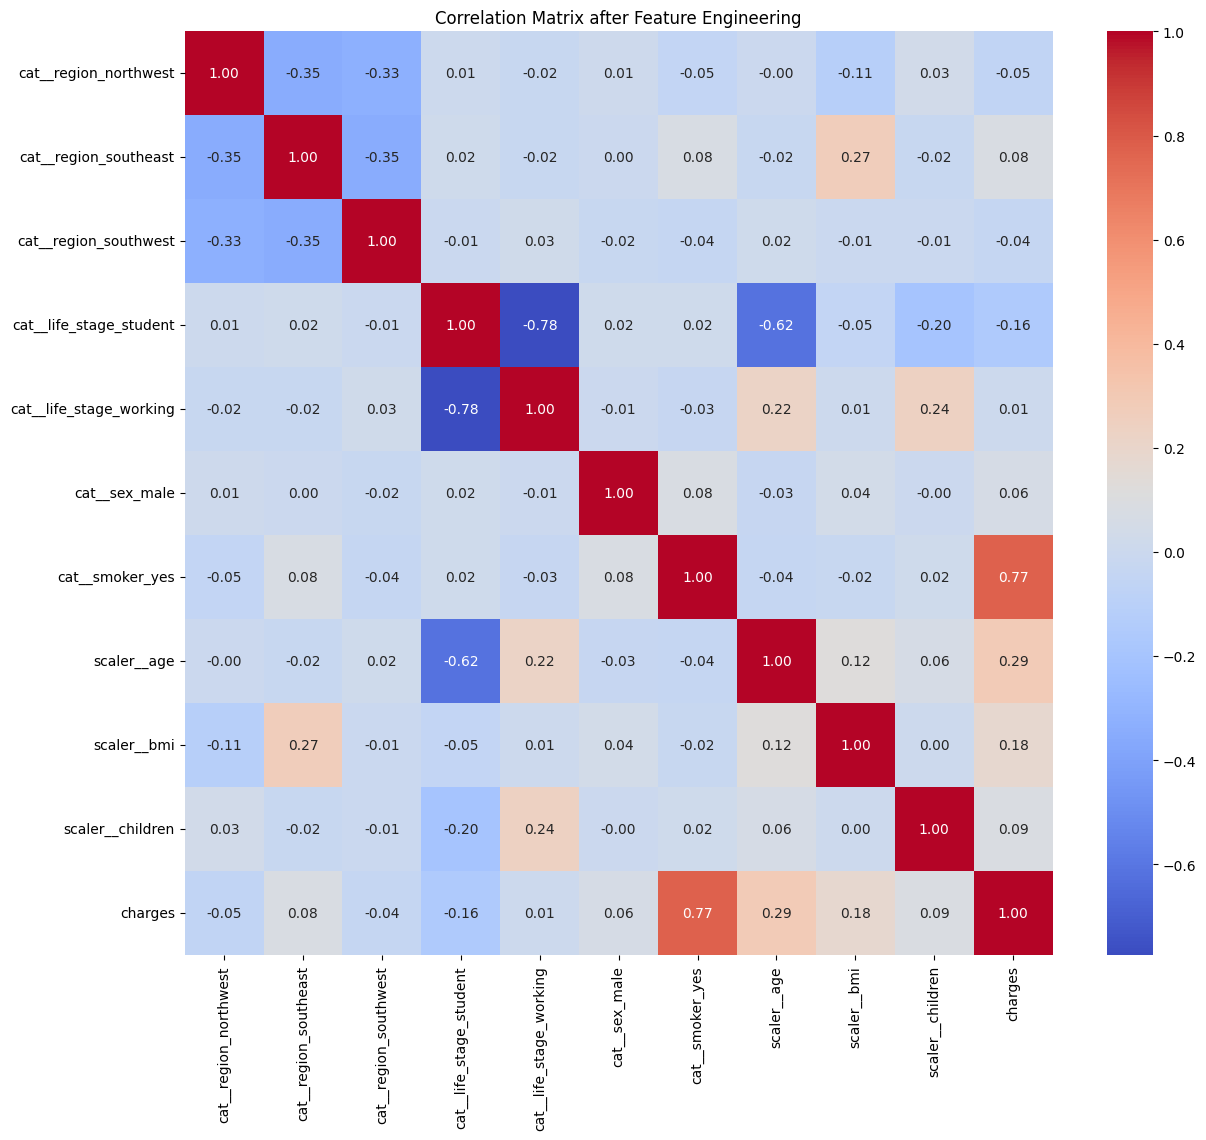

In [16]:
df_corr = x_train_df.copy()
df_corr['charges'] = y_train.values

corr_matrix = df_corr.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix after Feature Engineering")
plt.show()




# Model Training

In [17]:
def plot_actual_vs_predicted_by_index(y_test, y_pred, model_name):

    y_pred_series = pd.Series(np.asarray(y_pred), index=y_test.index)

    sorted_index = y_test.sort_index().index
    actual_sorted = y_test.loc[sorted_index]
    pred_sorted = y_pred_series.loc[sorted_index]

    plt.figure(figsize=(10, 6))
    plt.scatter(sorted_index, actual_sorted, alpha=0.5, s=25, color='steelblue', label='Actual Charges')
    plt.plot(sorted_index, pred_sorted, color='red', linewidth=1, label='Predicted (model)')
    plt.xlabel('Test Set Row Index (original dataset index)')
    plt.ylabel('Charges')
    plt.title(f'{model_name} — Actual vs Predicted')
    plt.legend()
    plt.show()


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr_model = LinearRegression()
lr_model.fit(x_train_final, y_train)

y_pred_lr = lr_model.predict(x_test_final)
print(f"Linear Regression — R² on test set: {r2_score(y_test, y_pred_lr):.4f}")


Linear Regression — R² on test set: 0.8044


In [19]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
print(f"Linear Regression — RMSE on test set: {rmse:.4f}")

Linear Regression — RMSE on test set: 5994.8758


In [20]:
from sklearn.metrics import mean_absolute_error

mse = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
print(f"Linear Regression — MAE on test set: {rmse:.4f}")

Linear Regression — MAE on test set: 64.9191


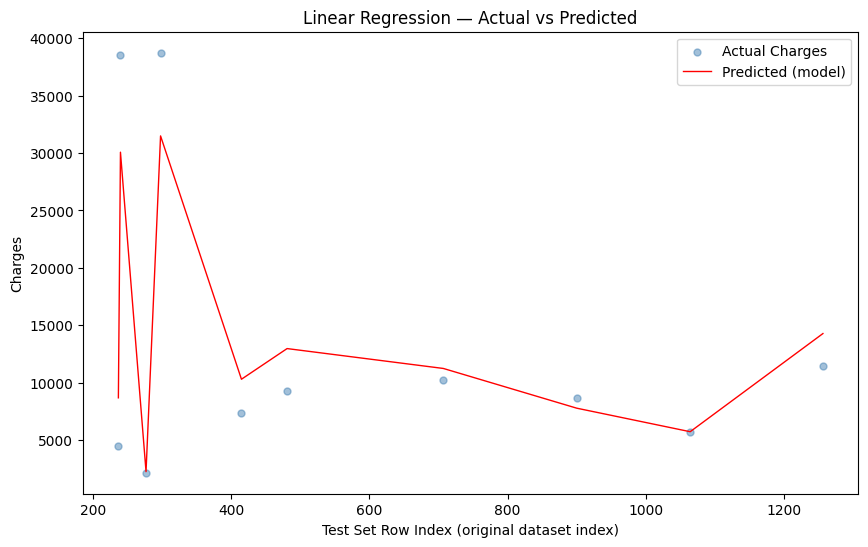

In [21]:
P = y_test[:10]
C= y_pred_lr[:10]
plot_actual_vs_predicted_by_index(P, C, 'Linear Regression')


### SGDRegressor Model

#### Preparation needed before training: scale the target (y)


In [22]:
from sklearn.preprocessing import StandardScaler
sgd_y_scaler = StandardScaler()
y_train_scaled_sgd = sgd_y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()


In [23]:
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(random_state=42, max_iter=1000 )
sgd_model.fit(x_train_final, y_train_scaled_sgd)

y_pred_sgd_scaled = sgd_model.predict(x_test_final)
y_pred_sgd = sgd_y_scaler.inverse_transform(y_pred_sgd_scaled.reshape(-1, 1)).ravel()

print(f"SGD Regressor — R² on test set: {r2_score(y_test, y_pred_sgd):.4f}")


SGD Regressor — R² on test set: 0.7951


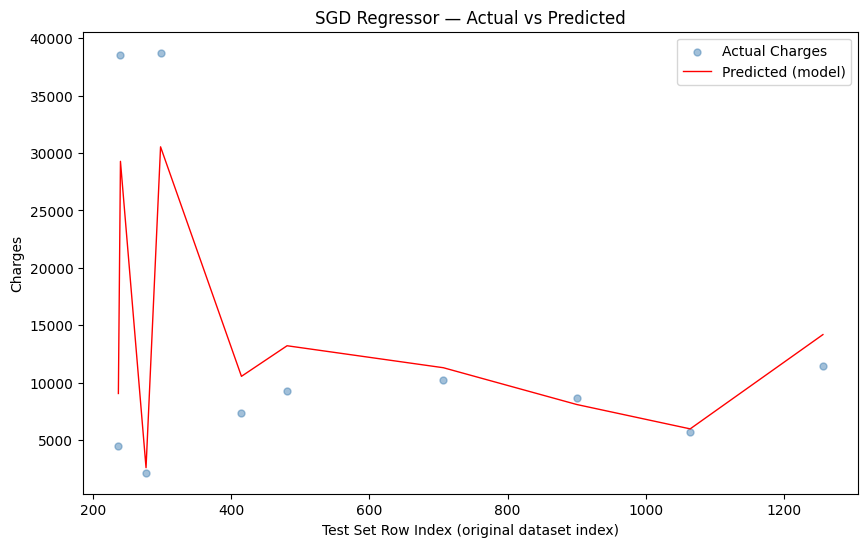

In [24]:
P = y_test[:10]
C= y_pred_sgd[:10]
plot_actual_vs_predicted_by_index(P, C, 'SGD Regressor')


### Lasso Regression Model

In [25]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(random_state=42)
lasso_model.fit(x_train_final, y_train)

y_pred_lasso = lasso_model.predict(x_test_final)
print(f"Lasso Regression — R² on test set: {r2_score(y_test, y_pred_lasso):.4f}")

Lasso Regression — R² on test set: 0.8043


In [26]:
P = y_test[:10]
P


,charges
900,8688.85885
1064,5708.86700
1256,11436.73815
298,38746.35510
237,4463.20510
481,9304.70190
240,38511.62830
277,2150.46900
415,7345.72660
707,10264.44210


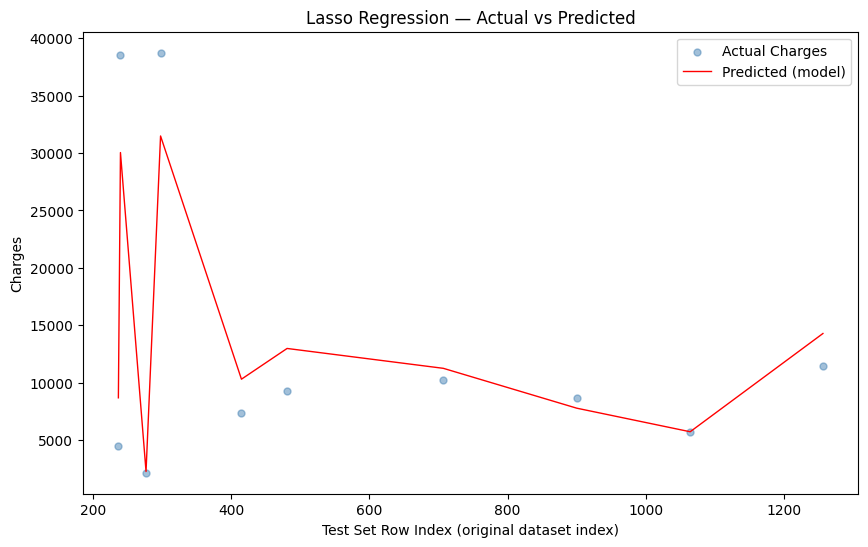

In [27]:
P = y_test[:10]
C= y_pred_lasso[:10]
plot_actual_vs_predicted_by_index(P, C, 'Lasso Regression')

### ElasticNet Regression Model

#### Preparation needed before training: tune alpha & l1_ratio (default params over-regularize and underfit)


In [28]:
from sklearn.linear_model import ElasticNetCV

elastic_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    cv=5,
    random_state=42,
    max_iter=10000
)
elastic_cv.fit(x_train_final, y_train)

best_alpha = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_
print(f"Best alpha: {best_alpha:.4f} | Best l1_ratio: {best_l1_ratio:.4f}")


Best alpha: 19.3430 | Best l1_ratio: 1.0000


In [29]:
from sklearn.linear_model import ElasticNet

elastic_net_model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, random_state=42)
elastic_net_model.fit(x_train_final, y_train)

y_pred_elastic_net = elastic_net_model.predict(x_test_final)
print(f"ElasticNet Regression — R² on test set: {r2_score(y_test, y_pred_elastic_net):.4f}")


ElasticNet Regression — R² on test set: 0.8029


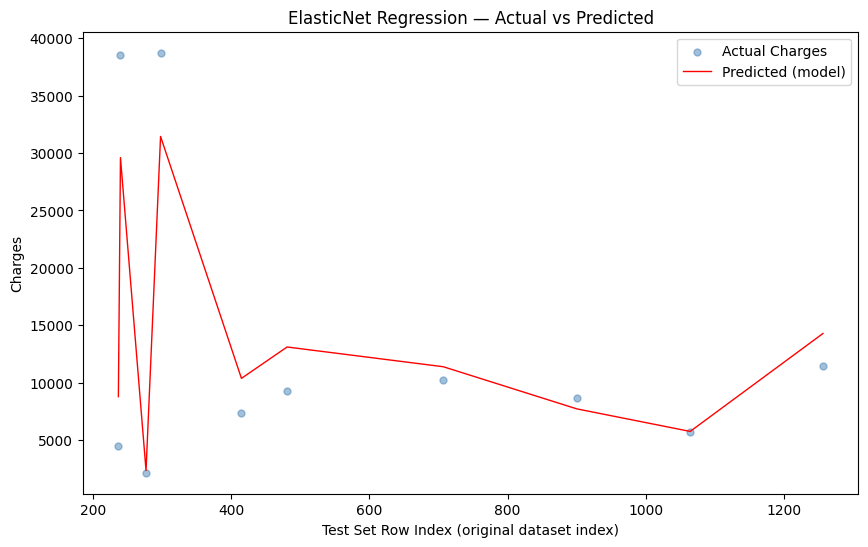

In [30]:
C= y_pred_elastic_net[:10]
plot_actual_vs_predicted_by_index(P, C, 'ElasticNet Regression')


### SVR (Support Vector Regressor) Model

#### Preparation needed before training: scale the target (y)


In [31]:
from sklearn.preprocessing import StandardScaler
svr_y_scaler = StandardScaler()
y_train_scaled_svr = svr_y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()


In [32]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(x_train_final, y_train_scaled_svr)

y_pred_svr_scaled = svr_model.predict(x_test_final)
y_pred_svr = svr_y_scaler.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

print(f"SVR (RBF Kernel) — R² on test set: {r2_score(y_test, y_pred_svr):.4f}")


SVR (RBF Kernel) — R² on test set: 0.8628


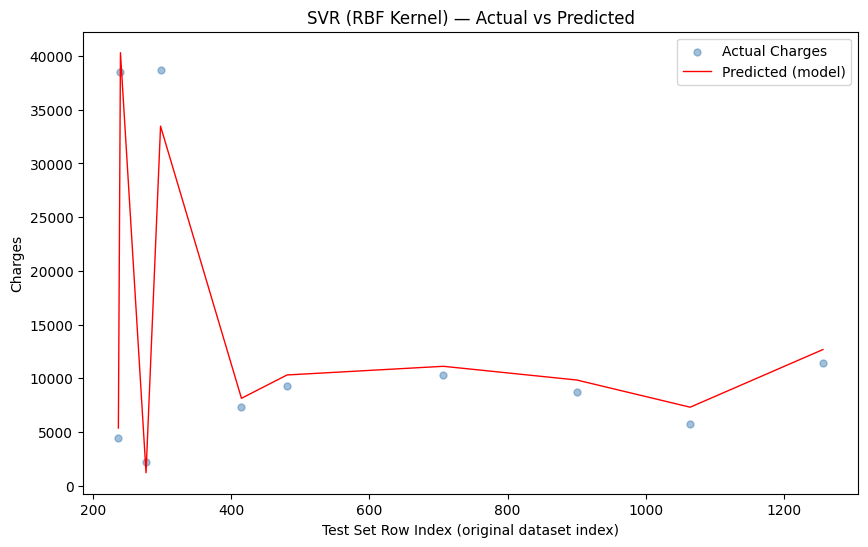

In [33]:
C= y_pred_svr[:10]
plot_actual_vs_predicted_by_index(P, C, 'SVR (RBF Kernel)')


### GradientBoostingRegressor Model (Ensemble Regressor)

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(x_train_final, y_train)

y_pred_gbr = gbr_model.predict(x_test_final)
print(f"GradientBoostingRegressor — R² on test set: {r2_score(y_test, y_pred_gbr):.4f}")

GradientBoostingRegressor — R² on test set: 0.9024


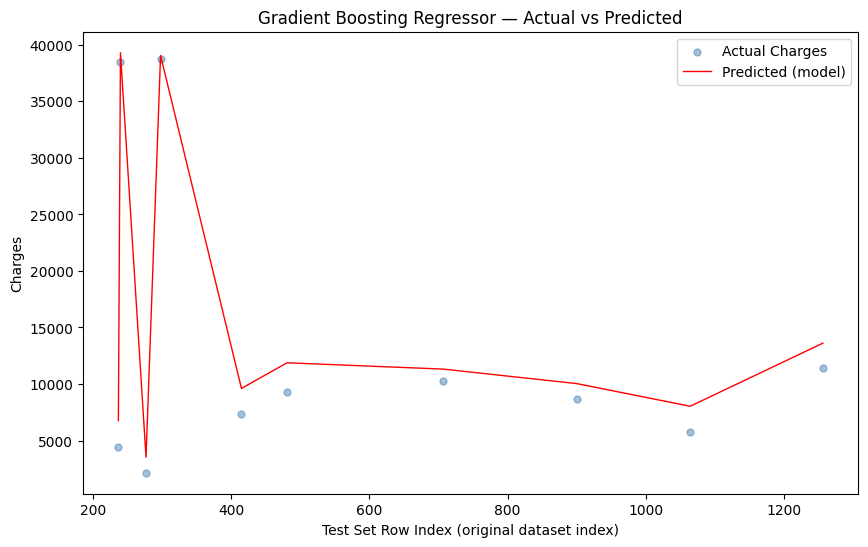

In [35]:
C= y_pred_gbr[:10]
plot_actual_vs_predicted_by_index(P, C, 'Gradient Boosting Regressor')


### XGBoostRegressor Model (Ensemble Regressor)

In [36]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(x_train_final, y_train)

y_pred_xgb = xgb_model.predict(x_test_final)
print(f"XGBoostRegressor — R² on test set: {r2_score(y_test, y_pred_xgb):.4f}")

XGBoostRegressor — R² on test set: 0.8635


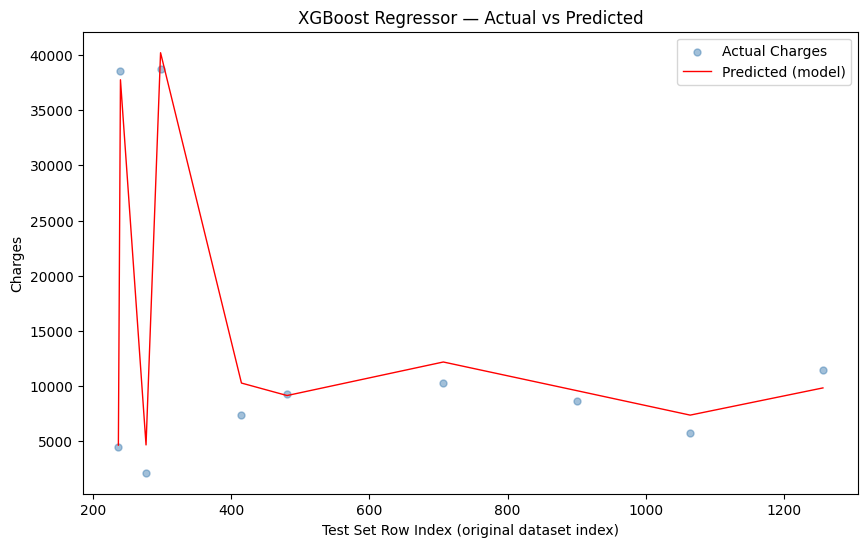

In [37]:
C= y_pred_xgb[:10]
plot_actual_vs_predicted_by_index(P, C, 'XGBoost Regressor')


### Ridge Regression Model

In [38]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(random_state=42)
ridge_model.fit(x_train_final, y_train)

y_pred_ridge = ridge_model.predict(x_test_final)
print(f"Ridge Regression — R² on test set: {r2_score(y_test, y_pred_ridge):.4f}")

Ridge Regression — R² on test set: 0.8034


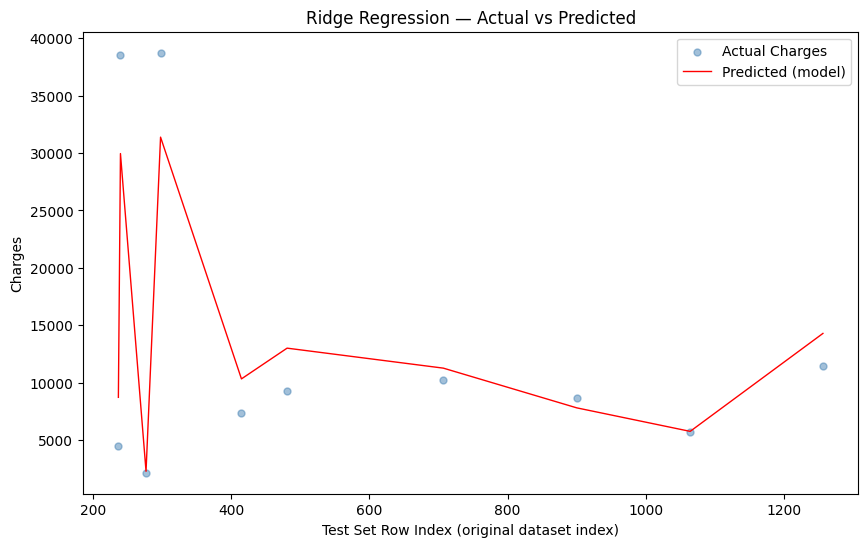

In [39]:
C= y_pred_ridge[:10]
plot_actual_vs_predicted_by_index(P, C, 'Ridge Regression')


# Model Comparison


In [40]:
from sklearn.metrics import mean_absolute_error

results = {
    'Linear Regression': y_pred_lr,
    'SGD Regressor': y_pred_sgd,
    'Lasso Regression': y_pred_lasso,
    'ElasticNet Regression': y_pred_elastic_net,
    'SVR (RBF Kernel)': y_pred_svr,
    'Gradient Boosting Regressor': y_pred_gbr,
    'XGBoost Regressor': y_pred_xgb,
    'Ridge Regression': y_pred_ridge,
}

comparison_rows = []
for name, preds in results.items():
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    comparison_rows.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

comparison_df = pd.DataFrame(comparison_rows).sort_values(by='R2', ascending=False).reset_index(drop=True)
display(comparison_df)


,Model,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.902365,4235.692945,2480.190505
1,XGBoost Regressor,0.863474,5008.734808,2890.068731
2,SVR (RBF Kernel),0.862846,5020.244132,2688.927302
3,Linear Regression,0.804423,5994.875819,4214.490558
4,Lasso Regression,0.804333,5996.255922,4214.987214
5,Ridge Regression,0.803420,6010.222444,4230.856091
6,ElasticNet Regression,0.802923,6017.812604,4223.792088
7,SGD Regressor,0.795114,6135.884961,4375.162425


/tmp/ipykernel_1897/1292916998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=comparison_df, palette='viridis')


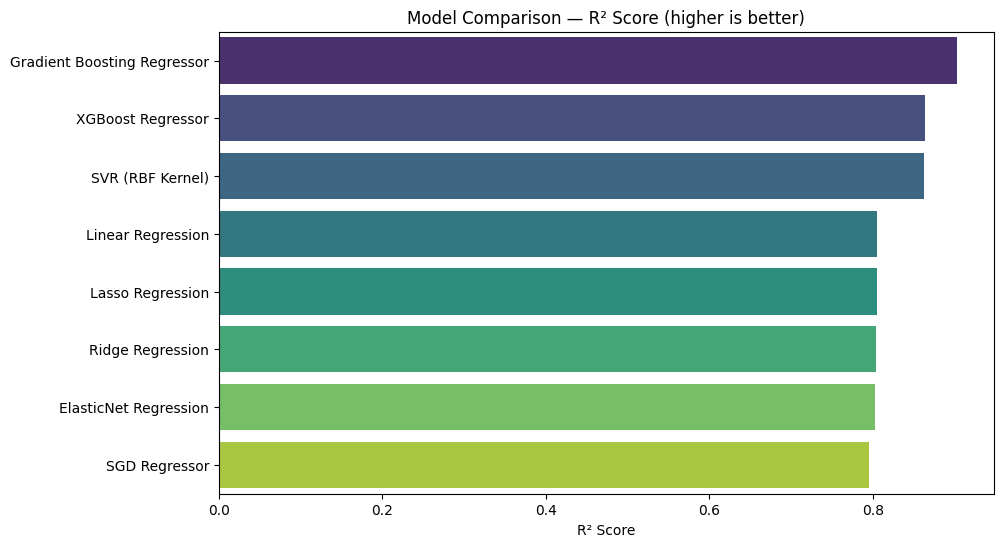

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x='R2', y='Model', data=comparison_df, palette='viridis')
plt.title('Model Comparison — R² Score (higher is better)')
plt.xlabel('R² Score')
plt.ylabel('')
plt.show()
